# Heart rate extraction from a PPG signal
## Cristina Papi, Marco Rosato

Heart rate extraction from a PPG signal is performed through a denoising stage based on a Butterworth filter, followed by frequency-domain analysis using FFT and peak detection to compute the BPM.
The dataset that we considered is BIDMC PPG and Respiration (physio net), where we can find four main csv:
- bidmc_##_Signals.csv: physiological signals (time series)
- bidmc_##_Numerics.csv: physiological parameters (ground truth)
- bidmc_##_Breaths.csv: manual breath annotations
- bidmc_##_Fix.txt: fixed variables (metadata of the subjects)

The main objective is the recovery and extraction of physiological information from degraded sources (Gaussian White Noise). We validate our algorithms through synthetic and controlled signal degradation.

The Butterworth filter is selected because it offers a very smooth response in the passband, ensuring that noise is suppressed without distorting the physiological shape of the PPG pulses.

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks
import matplotlib.pyplot as plt
np.random.seed(42)

We download the dataset:

In [ ]:
# Mount Google Drive
drive.mount('/content/gdrive')

#Percorso ai CSV
DATA_PATH = '/content/gdrive/MyDrive/Digital Signal & Image Management - Cristina Papi, Marco Rosato/Module 1/bidmc_csv/'

fs = 125  # Signals sampling frequency: 125 Hz -> we controlled it on the Fix.txt file

snr_levels = [20, 10, 5, 0] # we want to put the noise to arrive to these 4 level of SNR:
                            # 20 dB: high quality signal
                            # 10 db: moderate noise
                            # 5 db: significant noise
                            # 0 dB extreme noise (bad)

WINDOW = 8 * fs # window
STEP = WINDOW // 2 # 50% overlap

Mounted at /content/gdrive


In real-world scenarios, the heart rate is dynamic, accelerating and decelerating due to physiological factors such as arrhythmias, respiration, and stress. Segmentation allows us to track these heart rate variations over time rather than just calculating a single static average.

Windowing is indispensable for simulating the behavior of real-time monitoring devices, such as smartwatches, which update heart rate readings every few seconds.

The use of an overlap (STEP) is useful to prevent the loss of information that might otherwise be 'clipped' at the window boundaries.

Definition of two important functions that we will use during the project:
- Gaussian White Noise: it is useful to add Gaussian White Noise in our ppg
- Butterworth Filter: this filter helps us to not consider the noise in our signal.  
The purpose is to see if this filter is good to calculate the bpm without been subjective to noise

### Gaussian White Noise

We chose White Gaussian Noise because it is a standard statistical model in signal processing. It allows us to simulate random noise that affects all frequencies equally, mimicking the thermal and electronic noise found in real-world PPG sensors

In [ ]:
# Gaussian White Noise

def add_synthetic_noise(ppg, target_snr_db):
    """Injects Additive White Gaussian Noise (AWGN) to simulate sensor interference"""
    ppg_ac = ppg - np.mean(ppg) # DC removal -> focus only on the AC component for power calculation
    sig_power = np.mean(ppg_ac**2)
    sig_avg_db = 10 * np.log10(sig_power + 1e-12)
    noise_avg_db = sig_avg_db - target_snr_db # noise to achieve SNR target value
    noise_avg_watts = 10 ** (noise_avg_db / 10)
    noise = np.random.normal(0, np.sqrt(noise_avg_watts), len(ppg))
    return ppg_ac + noise

### Comparison of different types of filter

Although the Butterworth filter can be implemented in different modes (low-pass, high-pass, band-pass, band-stop), the band-pass configuration was selected as the main approach, as it best isolates the heart rate frequency band (0.5–4 Hz). Other configurations were tested  to compare how different frequency bands impact the recovery of the signal.

Band-pass: allows only frequencies within a specific range to pass through, removing both low-frequency and high-frequency noise

Low-pass: allows frequencies below a cutoff value to pass and attenuates higher frequencies

High-pass: allows frequencies above a cutoff value to pass and removes low-frequency components

Band-stop: attenuates frequencies within a selected range while keeping the rest of the spectrum



In [ ]:
# Butterworth Filter

def ppg_filter(data, fs, mode="bandpass", lowcut=0.5, highcut=4.0, order=4):
    nyq = 0.5 * fs  # Nyquist frequency (highest frequency that can be accurately represented in a digital signal -> fs/2)
    low = lowcut / nyq   #Normalized Frequencies
    high = highcut / nyq

    if mode == 'lowpass':
        b, a = butter(order, high, btype='low')
    elif mode == 'highpass':
        b, a = butter(order, low, btype='high')
    elif mode == 'bandpass':
        b, a = butter(order, [low, high], btype='band')
    elif mode == 'bandstop':
        b, a = butter(order, [low, high], btype='bandstop')

    y = filtfilt(b, a, data) # zero phase distortion -> peaks aligned in the time domain

    return y


### Heart Rate Estimation Algorithms

We use two different domains for HR extraction:
- The **Fast Fourier Transform (FFT)** is a mathematical algorithm that converts the PPG signal from its original Time Domain (amplitude over time) to the Frequency Domain (power distribution across frequencies). It Identifies the dominant frequency peak. It separates the primary cardiac component from low-frequency baseline wander and high-frequency sensor noise and considers the entire window.
**Formula: BPM = Peak Frequency (Hz) × 60**

- The **Peaks Detection** is a time-domain technique used to identify the specific moments when the heart ejects blood into the peripheral vessels, known as systolic peaks. In a PPG signal, these are the local maxima of the waveform. It tracks the actual shape of the pulse wave. It is highly sensitive to noise.
The algorithm identifies the time indices of each valid systolic peak. It then calculates the Inter-Beat Interval (IBI), which is the time elapsed between two consecutive peaks.
**Formula: BPM = 60 / Mean IBI (seconds)**

In [ ]:
def estimate_hr_fft(ppg_recovered, fs):
    """
    Extracts BPM in the Frequency Domain.
    """
    sig = ppg_recovered - np.mean(ppg_recovered) # DC removal to eliminate the dominant
                                                 # 0 Hz peak (spectral leakage prevention), to center the signal around zero

    sig = sig * np.hamming(len(sig)) # Hamming window -> The Hamming window tapers the signal towards zero at the boundaries,
                                     # smoothing the transition and ensuring that the resulting spectral peak for the heart rate is well-defined

    fft_vals = np.abs(np.fft.rfft(sig))
    freqs = np.fft.rfftfreq(len(sig), 1/fs)

    mask = (freqs >= 0.5) & (freqs <= 4)
    peak_freq = freqs[mask][np.argmax(fft_vals[mask])] # Find the frequency with the highest magnitude within the mask

    return peak_freq * 60


In [ ]:
def estimate_hr_peaks(ppg_recovered, fs):
    """Extracts BPM in the Time Domain by detecting systolic peaks"""
    min_dist = int(fs * 0.3)  # minimum distance between peaks 0.3 s -> max 200 BPM

    peaks, _ = find_peaks(
        ppg_recovered,
        distance=min_dist,
        prominence=np.std(ppg_recovered)*0.5  # threshold based on signal quality
    )

    if len(peaks) < 2:
        return np.nan # Not enough peaks to compute interval, ex: if you don’t have at least 2 beats

    ibi = np.diff(peaks) / fs  # Calculate mean Inter-Beat Interval (IBI) and convert to BPM
    return 60 / np.mean(ibi)


In our project we validate our filter using two main metrics:
- Mean Absolute Error (MAE): it quantifies the average magnitude of the difference between the estimated BPM (calculated by our algorithms) and the ground truth BPM (provided by the dataset)
Formula:
$$MAE = \frac{1}{n} \sum_{i=1}^{n} |BPM_{calc, i} - BPM_{true, i}|$$
- Signal-to-Noise Ratio (SNR): it is a standard metric used in science and engineering to compare the level of a desired signal to the level of background noise. It is defined as the ratio of signal power to noise power, often expressed in decibels (dB). If positive -> signal power is higher than the noise power (good quality)
Formula:
$$SNR_{dB} = 10 \log_{10} \left( \frac{P_{signal}}{P_{noise}} \right)$$

In [ ]:
def calculate_snr(clean, test):
    """
    Compute the Signal-to-Noise Ratio (SNR) between the original signal and the filtered one.
    Both signals are centered to prevent the DC offset from affecting the calculation.
    """
    clean_centered = clean - np.mean(clean)
    test_centered = test - np.mean(test)
    noise = test_centered - clean_centered

    # Power computation (mean square value)
    ps = np.mean(clean_centered**2) # signal power
    pn = np.mean(noise**2)          # noise power

    # Computation of the ratio in dB (adding a small epsilon to prevent division by zero)
    return 10 * np.log10(ps / (pn + 1e-12))


### Analysis

We download the dataset, considering only the files about signals (a time series of the ppg) and numerics (that is our ground_truth, with the true values of bpm -> heart rate).

We iterate through all 53 subjects, applying the degradation and all 4 filtering strategies to calculate the final error (MAE) and signal quality (SNR) for each case.


In [ ]:
all_results = []
modes = ['bandpass','lowpass','highpass','bandstop']

for i in range(1, 54):

    file_num = f'{i:02d}'

    signals = pd.read_csv(f'{DATA_PATH}bidmc_{file_num}_Signals.csv')
    numerics = pd.read_csv(f'{DATA_PATH}bidmc_{file_num}_Numerics.csv')

    # Cleaning
    signals.columns = signals.columns.str.strip()
    numerics.columns = numerics.columns.str.strip()

    ppg = signals['PLETH'].values

    # Timeline
    t_ppg = np.arange(len(ppg)) / fs
    t_num = np.arange(len(numerics))  # approx 1 Hz

    # Interpolation of HR onto the PPG timeline to achieve temporal alignment
    hr_interp = np.interp(
    t_ppg,
    t_num,
    numerics['HR'].ffill().values) # HR: the value obtained from the ECG, providing validation of the PPG signal against the clinical gold standard.

    for snr_val in snr_levels: # different values of SNR

        # Segmentation
        for start in range(0, len(ppg)-WINDOW, STEP):

            seg_clean = ppg[start:start+WINDOW]
            # Pre-processing: remove DC before filtering to avoid filter transients
            seg_clean_centered = seg_clean - np.mean(seg_clean)

            # Add noise
            seg_noisy = add_synthetic_noise(seg_clean_centered, snr_val)
            true_bpm = np.mean(hr_interp[start:start+WINDOW])
            # Skip the window if the ground truth is not valid.
            if np.isnan(true_bpm):
              continue

            res = {           # Dictionary
                'id': i,
                'snr_target': snr_val,
                'true_bpm': true_bpm
            }

            # Filtering
            for m in modes: # different modes

                filtered = ppg_filter(seg_noisy, fs, mode=m)

                # Estimation
                hr_p = estimate_hr_peaks(filtered, fs)
                hr_f = estimate_hr_fft(filtered, fs)

                # Metrics
                res[f'mae_peaks_{m}'] = abs(hr_p - true_bpm)
                res[f'mae_fft_{m}'] = abs(hr_f - true_bpm)

                res[f'snr_out_{m}'] = calculate_snr(seg_clean, filtered)

            all_results.append(res.copy())

    print(f"Subject {file_num} processed")

# Convert results list to Dataframe for final statistical analysis
df_results = pd.DataFrame(all_results)

Subject 01 processed
Subject 02 processed
Subject 03 processed
Subject 04 processed
Subject 05 processed
Subject 06 processed
Subject 07 processed
Subject 08 processed
Subject 09 processed
Subject 10 processed
Subject 11 processed
Subject 12 processed
Subject 13 processed
Subject 14 processed
Subject 15 processed
Subject 16 processed
Subject 17 processed
Subject 18 processed
Subject 19 processed
Subject 20 processed
Subject 21 processed
Subject 22 processed
Subject 23 processed
Subject 24 processed
Subject 25 processed
Subject 26 processed
Subject 27 processed
Subject 28 processed
Subject 29 processed
Subject 30 processed
Subject 31 processed
Subject 32 processed
Subject 33 processed
Subject 34 processed
Subject 35 processed
Subject 36 processed
Subject 37 processed
Subject 38 processed
Subject 39 processed
Subject 40 processed
Subject 41 processed
Subject 42 processed
Subject 43 processed
Subject 44 processed
Subject 45 processed
Subject 46 processed
Subject 47 processed
Subject 48 pr

In [ ]:
df_results

,id,snr_target,true_bpm,mae_peaks_bandpass,mae_fft_bandpass,snr_out_bandpass,mae_peaks_lowpass,mae_fft_lowpass,snr_out_lowpass,mae_peaks_highpass,mae_fft_highpass,snr_out_highpass,mae_peaks_bandstop,mae_fft_bandstop,snr_out_bandstop
0,1,20,93.500,0.356655,4.000,8.950801,0.463554,4.000,14.507294,0.143587,4.000,11.303546,54.937500,63.500,0.265864
1,1,20,93.812,0.330259,3.688,8.301554,0.626615,3.688,14.537271,0.330259,3.688,10.647617,41.108635,63.812,0.338088
2,1,20,94.125,0.268593,3.375,10.834641,0.268593,3.375,14.445868,0.313615,3.375,13.673311,48.280063,64.125,0.392672
3,1,20,94.125,0.053082,3.375,11.568944,0.053082,3.375,14.728920,0.053082,3.375,13.866162,59.092569,64.125,0.403517
4,1,20,94.000,0.036446,3.500,9.549759,0.070696,3.500,14.345297,0.936709,3.500,10.465316,47.509434,64.000,0.455857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25223,53,0,89.240,3.980339,0.760,9.115329,3.980339,0.760,10.805529,61.713390,0.760,-0.138614,72.630504,51.740,-2.763400
25224,53,0,98.121,10.196029,0.621,4.440915,8.153715,0.621,10.328859,58.291930,0.621,-0.996715,48.032846,60.621,-3.201713
25225,53,0,98.192,6.728585,30.692,6.024252,1.919235,30.692,9.913114,42.140640,30.692,-0.993293,49.936898,134.308,-2.741143
25226,53,0,93.627,5.598831,3.627,5.769227,6.010178,3.627,10.342531,63.936025,3.627,-0.561853,52.977938,63.627,-2.223852


### Visual Comparison of PPG Signal Degradation at different SNR levels

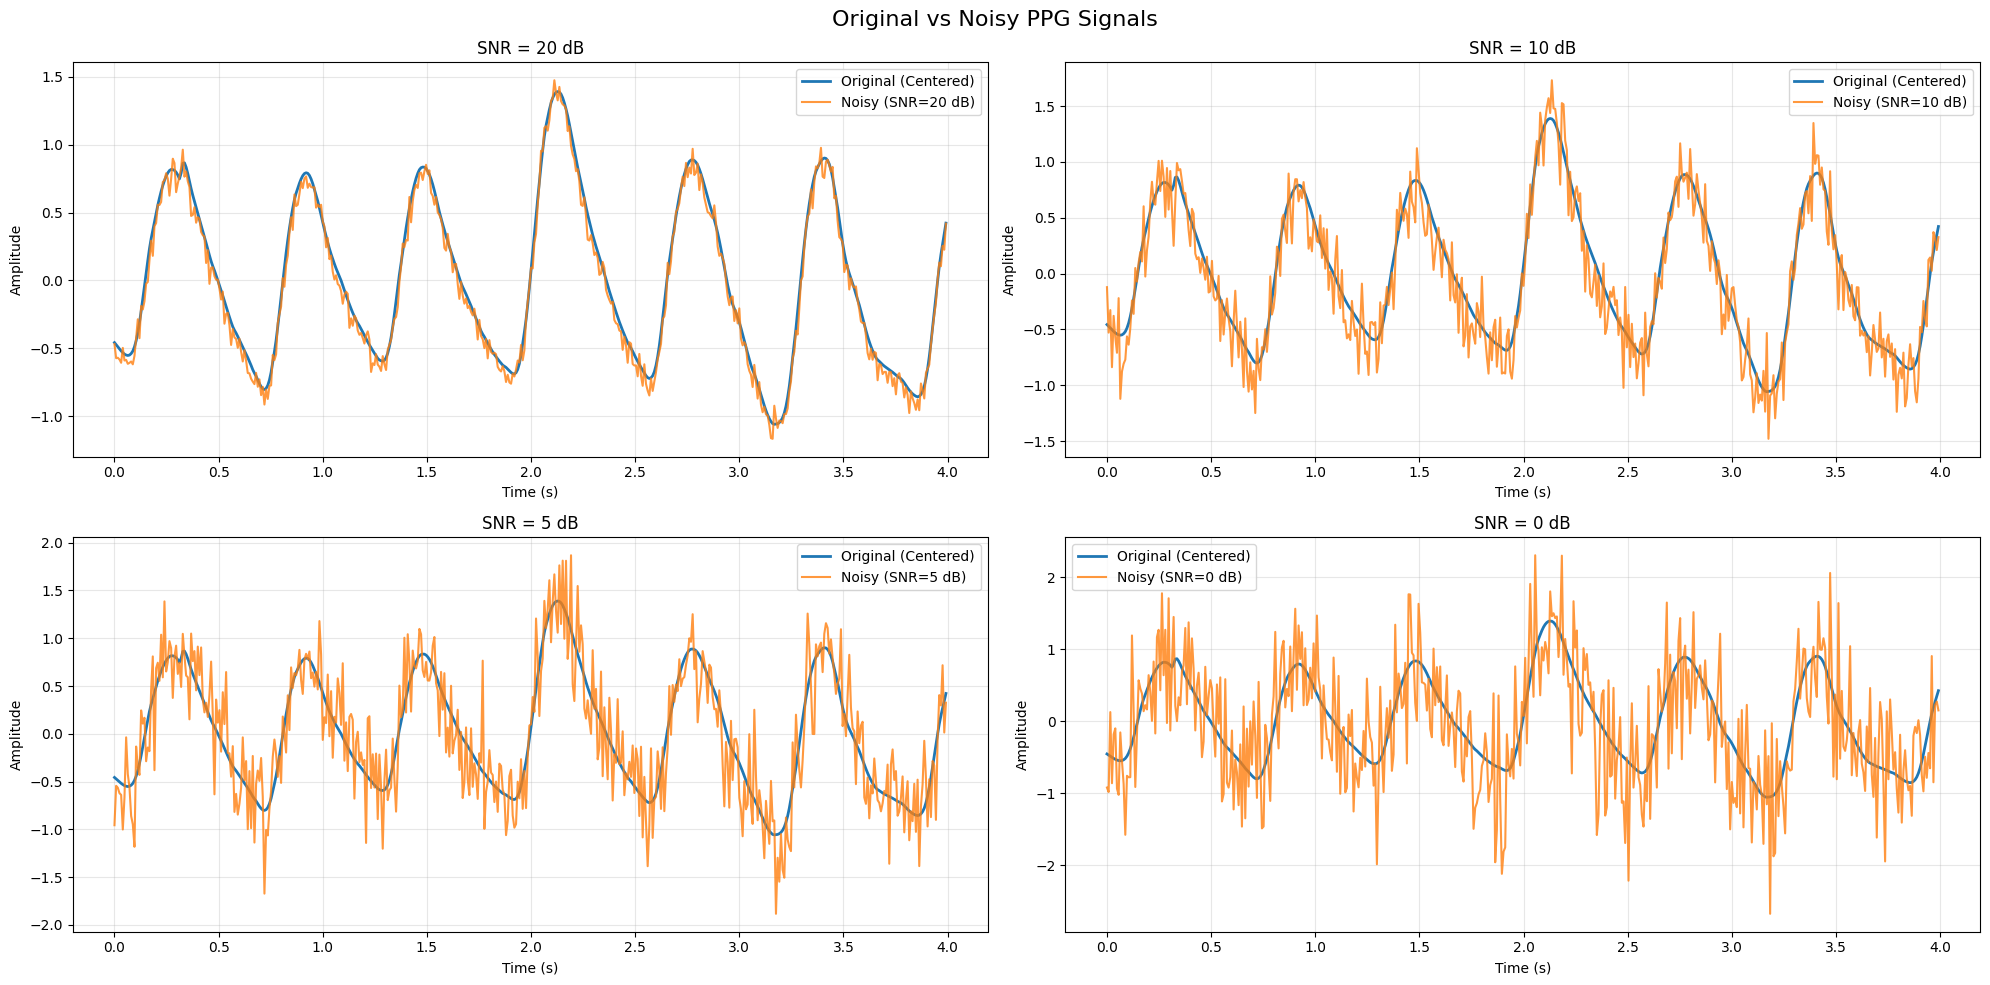

In [ ]:
# Visualization Parameters
snr_to_show = [20, 10, 5, 0]
start, end = 0, 500
t_vis = np.arange(start, end) / fs
ppg_base = ppg[start:end]

# Create 4 separate subplots
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
axes = axes.flatten()

for idx, snr_val in enumerate(snr_to_show):

    # Noisy signal
    ppg_noisy_full = add_synthetic_noise(ppg, snr_val)
    segment_noisy = ppg_noisy_full[start:end]

    ax = axes[idx]

    # Plot
    ax.plot(t_vis, ppg_base - np.mean(ppg_base), label='Original (Centered)', linewidth=2)

    ax.plot(t_vis, segment_noisy,
            label=f'Noisy (SNR={snr_val} dB)',
            alpha=0.8)

    ax.set_title(f"SNR = {snr_val} dB")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle("Original vs Noisy PPG Signals", fontsize=16)
plt.tight_layout()
plt.show()



The following plots illustrate the synthetic degradation of the original PPG signal (blue) through the injection of Additive White Gaussian Noise (AWGN) (orange). We evaluated four different levels of Signal-to-Noise Ratio (SNR): 20 dB, 10 dB, 5 dB, and 0 dB. As the SNR decreases, the high-frequency components of the noise increasingly mask the systolic peaks, demonstrating the necessity of a filtering stage (Butterworth) to recover the cardiac rhythm in real-world conditions.

In [ ]:
# Average global MAE for each method

print("Average global MAE for each configuration:")
print(df_results.mean())

Average global MAE for each configuration:
id                    27.000000
snr_target             8.750000
true_bpm              89.180843
mae_peaks_bandpass     4.628634
mae_fft_bandpass       4.571734
snr_out_bandpass       7.832938
mae_peaks_lowpass      4.380108
mae_fft_lowpass        4.650637
snr_out_lowpass       14.954709
mae_peaks_highpass    47.273220
mae_fft_highpass       4.623313
snr_out_highpass       4.708903
mae_peaks_bandstop    58.352676
mae_fft_bandstop      78.516879
snr_out_bandstop      -0.601329
dtype: float64


**Analysis of the results**



*   Bandpass Filter: low MAE (around 4.62-4.57), positive SNR (7.83 dB)
*   Lowpass Filter: low MAE (around 4.38-4.65), nearly identical to the Bandpass results. In this case the SNR is higher (14.95 dB).
*   Highpass Filter: in this case the FFT remains stable (MAE 4.62), while peak detection fails significantly (MAE 47.27). Highpass filter removes the DC offset but leaves all high-frequency noise intact. The FFT can ignore this and focus on the dominant frequency, instead the Peak detection is susceptible to high-frequency artifacts, mistaking every noise spike for a systolic peak
*   Bandstop Filter: both algorithms fail completely, with errors around 58-78. The Bandstop filter was designed to remove the 0.5–4.0 Hz frequency band. Since this band contains all relevant physiological information for heart rate, its removal leaves only noise





In [ ]:
df_test = pd.DataFrame(all_results)

# Display only the first 5 rows for Peak Detection
print("--- CHECK MAE PEAK VALUES ---")
columns_peaks = [col for col in df_test.columns if 'mae_peaks' in col]
print(df_test[columns_peaks].head())

# Display the first 5 rows for the FFT
print("\n--- CHECK FFT MAE VALUES ---")
columns_fft = [col for col in df_test.columns if 'mae_fft' in col]
print(df_test[columns_fft].head())

--- CHECK MAE PEAK VALUES ---
   mae_peaks_bandpass  mae_peaks_lowpass  mae_peaks_highpass  \
0            0.356655           0.463554            0.143587   
1            0.330259           0.626615            0.330259   
2            0.268593           0.268593            0.313615   
3            0.053082           0.053082            0.053082   
4            0.036446           0.070696            0.936709   

   mae_peaks_bandstop  
0           54.937500  
1           41.108635  
2           48.280063  
3           59.092569  
4           47.509434  

--- CHECK FFT MAE VALUES ---
   mae_fft_bandpass  mae_fft_lowpass  mae_fft_highpass  mae_fft_bandstop
0             4.000            4.000             4.000            63.500
1             3.688            3.688             3.688            63.812
2             3.375            3.375             3.375            64.125
3             3.375            3.375             3.375            64.125
4             3.500            3.500          

### Comparison between the different values of SNR

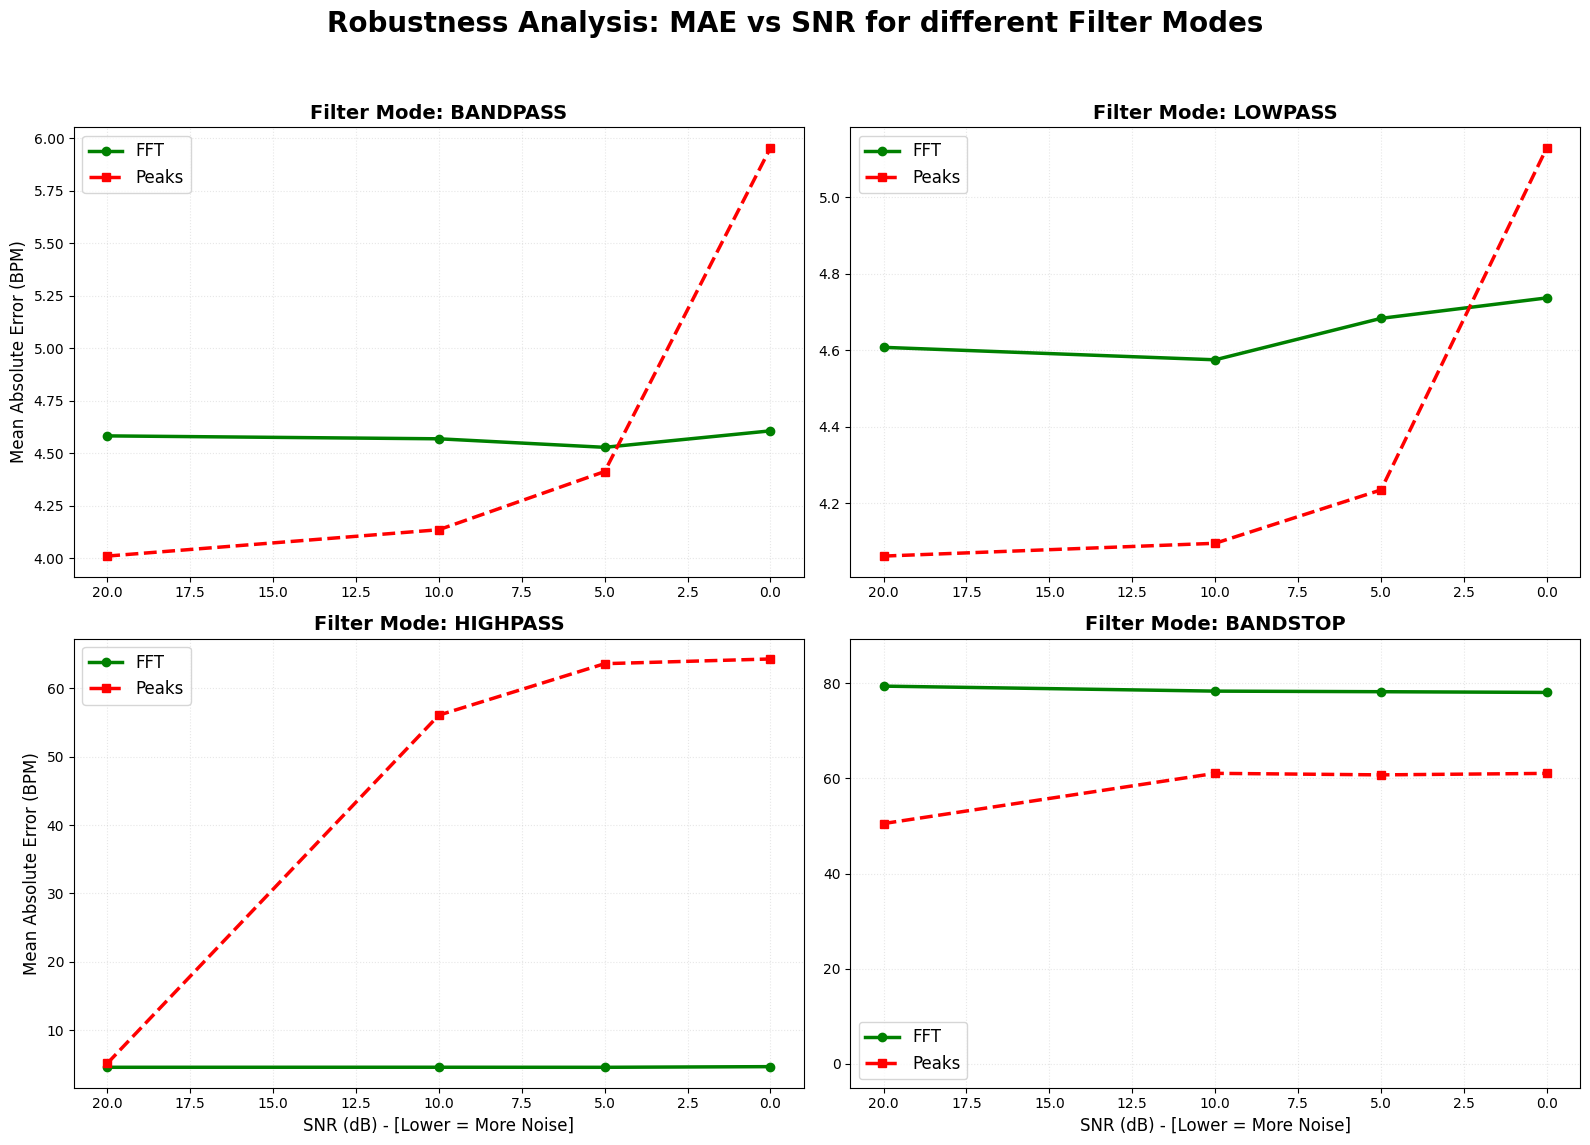

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Robustness Analysis: MAE vs SNR for different Filter Modes', fontsize=20, fontweight='bold')

# Map filters onto the grid
grid_map = {
    'bandpass': (0, 0),
    'lowpass':  (0, 1),
    'highpass': (1, 0),
    'bandstop': (1, 1)
}

# Compute the maximum MAE value to set a consistent limit (optional)
# This prevents the plot from being too "compressed" if there are huge outliers
max_mae = 0

for mode, pos in grid_map.items():
    ax = axes[pos]

    mae_fft_col = f'mae_fft_{mode}'
    mae_peaks_col = f'mae_peaks_{mode}'

    if mae_fft_col in df_results.columns and mae_peaks_col in df_results.columns:
        # Calculate the mean grouped by SNR
        subset = df_results.groupby('snr_target')[[mae_fft_col, mae_peaks_col]].mean().sort_index(ascending=False)

        # Update max_mae for the scale
        current_max = subset[[mae_fft_col, mae_peaks_col]].max().max()
        if current_max > max_mae: max_mae = current_max

        # FFT Plot and Peaks
        ax.plot(subset.index, subset[mae_fft_col], marker='o', label='FFT', color='green', linewidth=2.5)
        ax.plot(subset.index, subset[mae_peaks_col], marker='s', label='Peaks', color='red', linestyle='--', linewidth=2.5)
    else:
        continue

    ax.set_title(f"Filter Mode: {mode.upper()}", fontsize=14, fontweight='bold')

    # Invert the X-axis (from high SNR to low SNR) to see the noise effect
    if not ax.xaxis_inverted():
        ax.invert_xaxis()

    ax.grid(True, alpha=0.3, linestyle=':')
    ax.legend(fontsize=12)

    if pos[1] == 0: ax.set_ylabel("Mean Absolute Error (BPM)", fontsize=12)
    if pos[0] == 1: ax.set_xlabel("SNR (dB) - [Lower = More Noise]", fontsize=12)

# add margin
plt.ylim(-5, max_mae + 10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

The FFT-based method demonstrates remarkable robustness. Even at 5 dB SNR, the MAE remains relatively low. This is because the FFT integrates information over the entire window, making it less sensitive to localized noise spikes.

Instead, for the Peak Detection algorithm, as noise increases (SNR < 10 dB), the algorithm begins to register "false positive" peaks, leading to a significant surge in MAE, in particular for highpass and bandstop filters. Instead for bandpass and lowpass it remains low and constant.

### Analysis of the performances of our 4 types of filters

We analyze the performance of our algorithms. The Mean Absolute Error (MAE) serves as our primary accuracy metric.

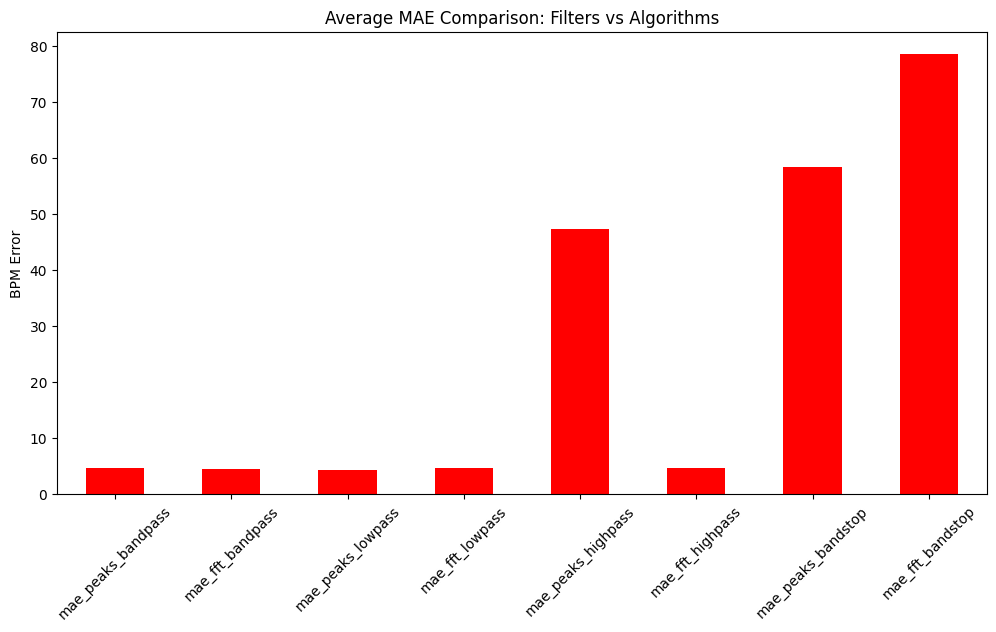

In [ ]:
# Method comparison

# Select only the MAE columns
mae_columns = [col for col in df_results.columns if 'mae_' in col]
df_results[mae_columns].mean().plot(kind='bar', figsize=(12, 6), color='red')
plt.title("Average MAE Comparison: Filters vs Algorithms")
plt.ylabel("BPM Error")
plt.xticks(rotation=45)
plt.show()

The Bandpass (BP) and Lowpass (LP) filters yield the most accurate results. The FFT method shows superior robustness with an average MAE of 4 BPM, while Peak Detection maintains a higher but stable error around 5 BPM.

A critical observation can be made in the Highpass (HP) scenario. While the FFT remains remarkably stable (thanks to its ability to identify the dominant frequency despite high-frequency noise), the Peak Detection MAE surges to ~60 BPM. This highlights that time-domain methods are highly susceptible to "false positive" peaks caused by high-frequency artifacts.

The Bandstop (BS) filter serves as a control group. The significant increase in MAE (~85 BPM for FFT and ~60 BPM for Peaks) validates that the heart rate information resides precisely within the 0.5–4.0 Hz frequency band, and its removal renders both algorithms ineffective.

### Example

Comparison between the 4 different modes to filter the noise for the subject 01

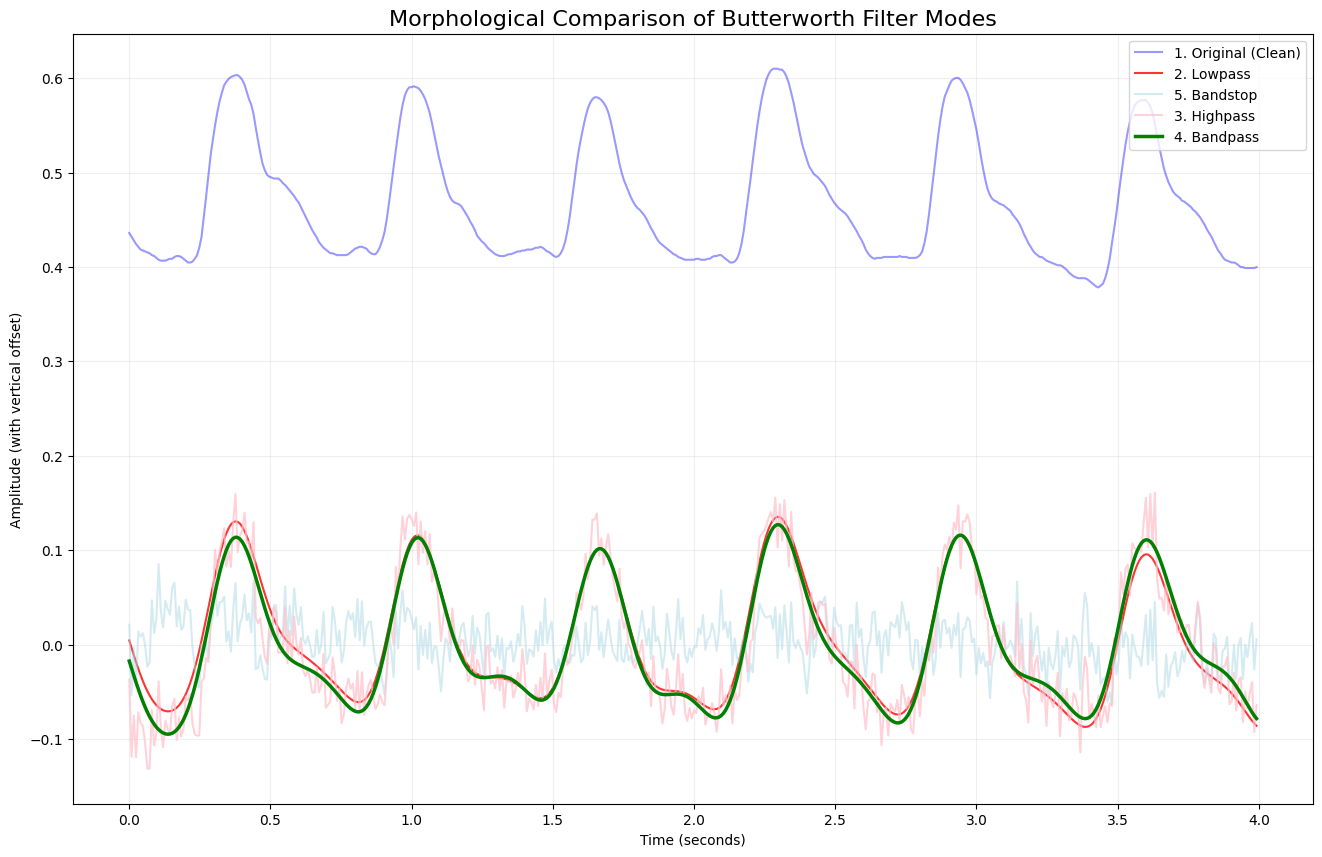

In [ ]:
# Load data
signals = pd.read_csv(f'{DATA_PATH}bidmc_01_Signals.csv')
numerics = pd.read_csv(f'{DATA_PATH}bidmc_01_Numerics.csv')

signals.columns = signals.columns.str.strip()
numerics.columns = numerics.columns.str.strip()

ppg = signals['PLETH'].values
bpm_reale = np.nanmean(numerics['HR'].values)

# Degradation with SNR=10
ppg_noisy_vis = add_synthetic_noise(ppg, 10)

# Filter
ppg_recovered_lp = ppg_filter(ppg_noisy_vis, fs, mode="lowpass")
ppg_recovered_hp = ppg_filter(ppg_noisy_vis, fs, mode="highpass")
ppg_recovered_bp = ppg_filter(ppg_noisy_vis, fs, mode="bandpass")
ppg_recovered_bs = ppg_filter(ppg_noisy_vis, fs, mode="bandstop")

# Selection of Subject 01 for visualization
start, end = 0, 500
t_vec = np.arange(start, end) / fs

plt.figure(figsize=(16, 10))

# Using Subject 01 data (ensure Subject 01 variables are loaded)
plt.plot(t_vec, ppg[start:end], label='1. Original (Clean)', color='blue', alpha=0.4)
plt.plot(t_vec, ppg_recovered_lp[start:end], label='2. Lowpass', color='red', alpha=0.8)
plt.plot(t_vec, ppg_recovered_bs[start:end], label='5. Bandstop', color='lightblue', alpha=0.5)
plt.plot(t_vec, ppg_recovered_hp[start:end], label='3. Highpass', color='pink', alpha=0.7)
plt.plot(t_vec, ppg_recovered_bp[start:end], label='4. Bandpass', color='green', linewidth=2.5)

plt.title("Morphological Comparison of Butterworth Filter Modes", fontsize=16)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (with vertical offset)")
plt.legend(loc='upper right')
plt.grid(alpha=0.2)

plt.show()


From the graph we can see that the two best modes to use are low pass and band pass.

- The Bandpass filter (green line) is the optimal choice. It combines the benefits of both Lowpass and Highpass: it centers the signal at zero and suppresses high-frequency noise. The result is a clean, rhythmic wave that preserves the morphological integrity of the systolic peaks, making it the most reliable input for both FFT and Peak Detection algorithms.

- The Lowpass filter successfully smooths the signal by removing high-frequency noise, but it fails to correct the vertical offset

- The Highpass filter removes the baseline but leaves high-frequency artifacts

- The bandstop eliminates the cardiac pulse waves, leaving only residual noise.

### SNR results comparison for each noise level

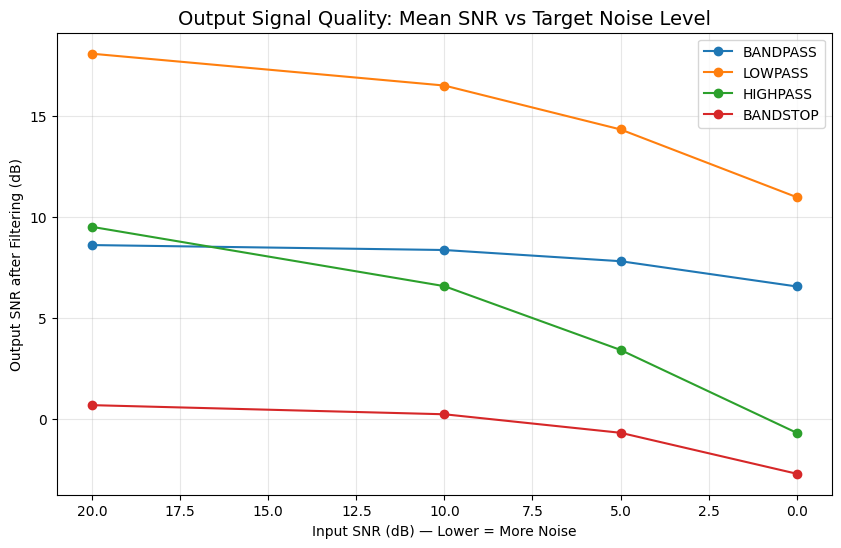

In [ ]:
plt.figure(figsize=(10,6))

modes = ['bandpass','lowpass','highpass','bandstop']

for m in modes:
    col = f'snr_out_{m}'

    # Compute the mean output SNR for each simulated noise level
    subset = df_results.groupby('snr_target')[col].mean().sort_index(ascending=False)

    plt.plot(subset.index, subset.values, marker='o', label=m.upper())

# Invert x-axis to show decreasing input SNR (as done for MAE)
plt.gca().invert_xaxis()

plt.title("Output Signal Quality: Mean SNR vs Target Noise Level", fontsize=14)
plt.xlabel("Input SNR (dB) — Lower = More Noise")
plt.ylabel("Output SNR after Filtering (dB)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


This plot shows the average output SNR obtained after applying different filtering strategies across varying noise conditions. By comparing the curves, it is possible to evaluate how effectively each filter improves signal quality as the input SNR decreases. Filters that maintain higher output SNR values demonstrate greater robustness to noise and better preservation of the physiological signal.